## **Neural Steward:** ***Highlights the LSTM (Neural) and the Agent (Steward).***


In [40]:
requirements = """
crewai
crewai_tools
langchain-google-genai
tensorflow
pandas
numpy
scikit-learn
gspread
python-dotenv
langchain-chroma
pip
langchain_community
"""
with open("requirements.txt", "w") as f:
    f.write(requirements.strip())
print("✅ requirements.txt has been created and is ready for GitHub!")
!pip install -r requirements.txt -q

✅ requirements.txt has been created and is ready for GitHub!


## **CrewAI + Google Workspace Integration** ⚡
An end-to-end AI agent environment hosted in Colab.

   * Data Source: Google Sheets

   * Storage: Google Drive

   * Logic: CrewAI Multi-Agent Framework

In [41]:
from google.colab import auth, drive, userdata
from google.auth import default
import os
import pandas as pd
import gspread

# Install/Update core libraries
#!pip install -qU crewai crewai_tools gspread langchain-google-genai langchain-chroma langchain_community

# Mount Drive and Auth
drive.mount('/content/drive')
auth.authenticate_user()
creds, _ = default()
creds = creds.with_scopes(['https://www.googleapis.com/auth/spreadsheets', 'https://www.googleapis.com/auth/drive'])
client = gspread.authorize(creds)

# Set API Key
os.environ["GEMINI_API_KEY"] = userdata.get('GEMINI_API_KEY')
print("✅ Environment Authenticated and Drive Mounted.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Environment Authenticated and Drive Mounted.


## This section initializes **chroma_db** using **LangChain** and **Google Gemini embeddings**. It specifically focuses on transforming structured CSV data into a searchable format for **Retrieval-Augmented Generation** (RAG).

* **Data Ingestion:** Loading structured information from CSV files.

* **Vectorization:** Generating semantic embeddings using Google Gemini's embedding models to capture the underlying meaning of the text.

* **Indexing:** Storing these embeddings in ChromaDB to enable efficient similarity searches.

* **RAG Readiness:** Providing a retrieval mechanism that allows a Large Language Model (LLM) to reference specific, grounded data from the original source.

In [42]:
from langchain_chroma import Chroma
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.document_loaders import CSVLoader

# Initialize Embeddings
gemini_embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")

# Load Budget Targets
csv_file_path = '/content/drive/MyDrive/ITAI_Midterm_Project/Budget.csv'
loader = CSVLoader(file_path=csv_file_path)
docs = loader.load()

# Create Vector DB
budget_chroma_client = Chroma.from_documents(
    documents=docs,
    embedding=gemini_embeddings,
    persist_directory="./chroma_db"
)
print("✅ Budget.csv loaded into Vector Database.")

✅ Budget.csv loaded into Vector Database.


## **Implementation of a secure synchronization workflow**
 Transfers API keys and credentials from Google Drive to the local execution environment, enabling the Accountant Agent to function.

In [43]:
import os
import shutil

# 1. Define Paths
ROOT = '/content/drive/MyDrive/ITAI_2376_Project/'
# Path where you store your keys in Google Drive
drive_config_dir = '/content/drive/MyDrive/ITAI_Midterm_Project/'

# Define local destinations
os.makedirs('config', exist_ok=True)

# List of files to sync (Source Path, Destination Path)
files_to_sync = [
    (os.path.join(drive_config_dir, 'credentials.json'), 'config/credentials.json'),
    (os.path.join(drive_config_dir, 'crewai-financial-agent-567d9487f274.json'), 'config/service_account.json')
]

# 2. Execute Copy
for source, destination in files_to_sync:
    if os.path.exists(source):
        shutil.copy(source, destination)
        print(f"✅ Synced: {os.path.basename(source)} -> {destination}")
    else:
        print(f"🔴 MISSING IN DRIVE: {source}")

print("\n🚀 Config directory is ready for the Accountant Agent.")

✅ Synced: credentials.json -> config/credentials.json
✅ Synced: crewai-financial-agent-567d9487f274.json -> config/service_account.json

🚀 Config directory is ready for the Accountant Agent.


## **Initialization & Model Selection** ⚡

  * **Model Definition:** Selects gemini/gemini-3.1-flash-lite-preview as the stable Large Language Model (LLM) for the agents, noting a shift from a 2.5 version for budgetary optimization.

   * **Verification:** Imports the library and prints the active CrewAI version and Model ID to confirm a successful setup.

In [44]:
# Adding -q (quiet) and -U (upgrade)
os.environ['TFTF_CPP_MIN_LOG_LEVEL'] = '2'

# Uninstall potentially conflicting versions installed by other cells or prior runs
#!pip uninstall -yq crewai langchain-chroma chromadb crewai-tools

# Consolidate installations into a single command to allow pip to resolve dependencies
# Install chromadb first as it's a base dependency for langchain-chroma, which crewai uses.
# Pin crewai to the desired version and let pip resolve the compatible langchain-chroma version.
#!pip install -q chromadb==1.1.0 langchain-chroma crewai-tools 'crewai[tools]'

import crewai # Import crewai after all installations are done
# Define the model ID that worked in your environment list
STABLE_MODEL = "gemini/gemini-3.1-flash-lite-preview" #"gemini/gemini-2.5-flash-lite" Changing for budget reasoning
print(f"CrewAI version: {crewai.__version__}")
print(f"Using model: {STABLE_MODEL}")

CrewAI version: 1.14.4
Using model: gemini/gemini-3.1-flash-lite-preview


## **Client Initialization** ⚡

  * **Global Client:** Authorizes the gspread library with the scoped credentials.

  * **Instance Creation:** Defines a client object that serves as the primary interface for all subsequent spreadsheet operations (e.g., opening, reading, or updating sheets).

In [45]:
from google.colab import auth
import gspread
from google.auth import default
import pandas as pd

# 1. Authenticate the session
auth.authenticate_user()
creds, _ = default()

# 2. Add full Drive and Sheets scopes to the credentials to prevent 403 errors
creds = creds.with_scopes([
    'https://www.googleapis.com/auth/spreadsheets',
    'https://www.googleapis.com/auth/drive'
])

# 3. Define the global client
client = gspread.authorize(creds)
print("✅ Global Client authenticated with full Drive and Sheet scopes.")

✅ Global Client authenticated with full Drive and Sheet scopes.


## **Google Gemini Large Language Model (LLM) initialization** ⚡
 Using the **LangChain** framework, specifically configured for high-precision financial tasks.

In [46]:
from langchain_google_genai import ChatGoogleGenerativeAI

# Initialize the LLM with a Temperature of 0.0 for "Financial Accuracy"
# We use temperature=0 because we want the agents to be precise with
# your $5,626.19 surplus, not 'creative' with the math.
genai_llm = ChatGoogleGenerativeAI(
    model=STABLE_MODEL,
    temperature=0.0,
    google_api_key=os.environ["GEMINI_API_KEY"]
)

print(f"✅ LLM Engine Initialized: {STABLE_MODEL}")

✅ LLM Engine Initialized: gemini/gemini-3.1-flash-lite-preview


##  **Tools allow an AI agent to interface with financial data stored in local files and cloud-based spreadsheets**
1. #### **Budget RAG Tool (budget_rag_tool)**

  * **Purpose:** Acts as a retrieval mechanism for "fixed targets" or planned financial goals.
  * **Data Source:** Primarily references a Budget.csv file.
  * **Key Targets:** Explicitly looks for predefined budget caps, such as:
        *Mortgage: $1,658*
        *Utilities: $400*
        *Gasoline: $150*
        *Groceries: $800*
  * **Function:** Provides the agent with the "ideal" spending plan to compare against actual behavior.

2. #### **Live Transaction Tool (google_sheets_tool)**

* **Purpose:** Fetches real-time, "actual" spending data.
* **Data Source:** Connects to a Google Sheet using the gspread library.

* **Output:**
   * Retrieves all records and converts them into a Pandas DataFrame.
   * Returns the last 60 transactions to capture a "bi-monthly rhythm."
   * Formats the data as a string for the agent to process.

* **Error Handling:** Includes a try-except block to report connectivity issues with the Google Sheets API.

In [47]:
from crewai.tools import tool
import pandas as pd

# --- Tool 1: The Budget RAG (Goal Retrieval) ---
@tool("budget_rag_tool")
def budget_rag_tool_func(query: str) -> str:
    """
    Searches the Budget.csv for fixed targets.
    Use this to find what the Mortgage ($1,658), Utilites ($400), Gasoline ($150) and Groceries ($800) budgets are
    targets SHOULD be according to the plan.
    """
    # Uses the budget_chroma_client initialized in your RAG setup cell
    results = budget_chroma_client.similarity_search(query, k=5)
    content = "\n".join([f"TARGET DATA: {doc.page_content}" for doc in results])
    return content

# --- Tool 2: The Spending Sheet (Reality Retrieval) ---
@tool("read_spending_sheet")
def read_spending_sheet() -> str:
    """
    Connects to the live Budget Google Sheet.
    Use this to see ACTUAL spending history and identify bi-monthly
    'ACH Credit' income patterns.
    """
    # FIXED: Clean ID only - no extra text inside the quotes
    tid = '1KO7CpdOoL30cM73kg-6jiLkyz2wzgyR6IfdqcTV-NFI'

    try:
        # Use the global 'client' established in your Authentication cell
        sheet = client.open_by_key(tid).sheet1
        data = sheet.get_all_records()
        df = pd.DataFrame(data)

        # Return last 60 transactions so the Agent sees the full bi-monthly rhythm
        recent_data = df.tail(60).to_string(index=False)
        return f"ACTUAL TRANSACTION HISTORY:\n{recent_data}"
    except Exception as e:
        return f"Error connecting to Google Sheet: {str(e)}"

## **Two specialized AI agents using the CrewAI framework.**
 These agents are designed to function as a household financial management team, focusing on cash-flow stability and calendar-based logistics.
 * ***Agent 1* :** Lead Household Financial Steward

   * **Role:** Financial Analyst / Accountant.
   * **Primary Goal:** To monitor bi-monthly income cycles and identify "liquidity troughs" (periods of low cash flow).

 * ***Agent 2* :** Guardian of the Calendar

  * **Role:** Logistics Manager.

  * **Primary Goal:** To map financial constraints against the physical calendar to manage bill timing.

In [48]:
from crewai import Agent

# --- AGENT 1: THE ACCOUNTANT ---
steward = Agent(
    role="Lead Household Financial Steward",
    goal="Analyze bi-monthly income cycles to identify liquidity troughs and secure the primary residence mortgage.",
    backstory="""You are a veteran financial analyst focused on household cash-flow optimization.
    You excel at synthesizing raw transaction data and comparing it against fixed budget targets.
    Your primary directive is to protect the household's primary liabilities—mortgage, utilities,
    and insurance—from liquidity shortfalls. You are grounded in the 'Paychecks/Salary ACH Credit' rhythm
    and ensure the mandatory 20% safety buffer is always maintained.""",
    tools=[budget_rag_tool_func, read_spending_sheet],
    verbose=True,
    allow_delegation=False
)

# --- AGENT 2: THE SCHEDULER ---
scheduler = Agent(
    role="Strategic Bill & Liquidity Scheduler",
    goal="Transform forecasts into a prioritized 30-day action plan that coordinates bill dates with income.",
    backstory="""You are a precision-oriented logistics manager and the 'Guardian of the Calendar.'
    You take the financial constraints provided by the Steward and map them against the real-world
    calendar for the Primary Residence. You are responsible for issuing 'Spending Red Alerts'
    when bills overlap with low-cash windows. You provide clear instructions on 'Stability Focus'
    vs 'Growth Focus' weeks.""",
    verbose=True,
    allow_delegation=False
)

## **Multi-agent orchestration framework**

* **Library Imports:** Imports the essential classes from ***crewai (Agent, Task, Crew, Process)***
* **LangChain integration:** Google’s ChatGoogleGenerativeAI.
* **LLM Configuration:** Initializes a Google Generative AI model using a variable ***STABLE_MODEL***.
* **Tool Integration:** Contains placeholders for a GoogleCalendarTool, which is currently commented out, likely due to environment-specific import issues

In [49]:
from crewai import Agent, Task, Crew, Process
# from crewai_tools.tools import GoogleCalendarTool # Ensure you've installed crewai_tools and the tool is available here
from langchain_google_genai import ChatGoogleGenerativeAI # Import Google Generative AI Chat LLM

# Initialize the Google Generative AI LLM (this instance might not be directly used by agents anymore)
genai_llm = ChatGoogleGenerativeAI(model=STABLE_MODEL) # Removed verbose=True

# Initialize Tools (Add the Calendar tool here)
# calendar_tool = GoogleCalendarTool() # Temporarily commented out due to ImportError

# Define Agents
steward = Agent(
    role="Lead Household Financial Steward",
    goal="Analyze bi-monthly income cycles to automate a 30-day bill-payment schedule.",
    backstory="""Expert in Local cash-flow. You synthesize raw transaction data from spreadsheets
    to protect primary liabilities (Mortgages, Utilities, Groceries). You prioritize
    verified targets over raw predictions.""",
    tools=[budget_rag_tool_func, read_spending_sheet], # Steward audits the data
    llm=STABLE_MODEL,
    verbose=True
)

scheduler = Agent(
    role="Strategic Bill & Liquidity Scheduler",
    goal="Transform forecasts into a 30-day prioritized payment roadmap.",
    backstory="""Calendar Guardian for the Primary Residence. You cross-reference bill due dates
    from the Google Calendar with the Steward's liquidity troughs. You issue 'Spending Red Alerts'
    when calendar events overlap with low-cash windows.""",
    # tools=[calendar_tool], # Scheduler manages the timing, temporarily commented out
    llm=STABLE_MODEL,
    verbose=True
)

# Define the Integrated Task
# This task now explicitly asks the agents to use the calendar
analysis_task = Task(
    description="""
    1. Use the Steward to retrieve Household expense targets and identify 'State Check' ACH patterns.
    2. Use the Scheduler to scan the Google Calendar for upcoming 'Local' bill due dates.
    3. Synthesize this data to highlight 30-day troughs where liquidity is at risk.
    """,
    expected_output="A 30-day Financial Action Plan and Liquidity Roadmap mapped against the real-world calendar.",
    agent=steward
)

# Launch
itai_financial_crew = Crew(
    agents=[steward, scheduler],
    tasks=[analysis_task],
    process=Process.sequential,
    verbose=True
)

result = itai_financial_crew.kickoff()

╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: c339c955-fa2d-469a-b652-677cb2a7c559                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name:                                                                                                          │
│      1. Use the Steward to retrieve Household expense targets and identify 'State Check' ACH patterns.          │
│      2. Use the Scheduler to scan the Google Calendar for upcoming 'Local' bill due dates.                      │
│      3. Synthesize this data to highlight 30-day troughs where liquidity is at risk.                            │
│                                                                                                                 │
│  ID: 9ec62934-03b0-4f57-992f-eabe3a7d24af                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Lead Household Financial Steward                                                                        │
│                                                                                                                 │
│  Task:                                                                                                          │
│      1. Use the Steward to retrieve Household expense targets and identify 'State Check' ACH patterns.          │
│      2. Use the Scheduler to scan the Google Calendar for upcoming 'Local' bill due dates.                      │
│      3. Synthesize this data to highlight 30-day troughs where liquidity is at risk.                            │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────── 🔧 Tool Execution Started (#6) ─────────────────────────────────────────╮
│                                                                                                                 │
│  Tool: read_spending_sheet                                                                                      │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────── 🔧 Tool Execution Started (#6) ─────────────────────────────────────────╮
│                                                                                                                 │
│  Tool: budget_rag_tool                                                                                          │
│  Args: {'query': 'Mortgage, Utilities, Gasoline, Groceries targets'}                                            │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭─────────────────────────────────────── ✅ Tool Execution Completed (#6) ────────────────────────────────────────╮
│                                                                                                                 │
│  Tool Completed                                                                                                 │
│  Tool: read_spending_sheet                                                                                      │
│  Output: ACTUAL TRANSACTION HISTORY:                                                                            │
│  Posting Date Transaction Date  Amount Credit Debit Indicator       type Type Group Reference Instructed        │
│  Currency Currency Exchange Rate Instructed Amount                                    Description               │
│  Category Check Serial Number Card Ending Rewards Total Rewards Type                                            │
│    02/23/2026       02/23/2026  130.00                  Debit   Transfer   Transfer                             │
│  Transfer To Checking -1807           Transfers                                                                 │
│    02/23/2026       02/23/2026  100.00                  Debit   Transfer   Transfer                             │
│  Transfer To Checking -6259           Transfers                                                                 │
│    02/23/2026       02/21/2026   50.00                  Debit        POS        POS                             │
│  Transfer to Cash App           Transfers                                                                       │
│    02/23/2026       02/21/2026   25.94                  Debit        POS        POS                             │
│  Amazon Marketplace General Merchandise                                                                         │
│    02/20/2026       02/20/2026  475.00                  Debit   Transfer   Transfer                             │
│  Transfer To Credit Card -1806           Transfers                                                              │
│    02/20/2026       02/20/2026  345.00                  Debit   Transfer   Transfer                             │
│  Transfer To Credit Card -0711           Transfers                                                              │
│    02/19/2026       02/19/2026  175.00                  Debit  ACH Debit  ACH Debit                             │
│  Transfer to PayPal           Transfers             9100001                                                     │
│    02/19/2026       02/18/2026    6.39                  Debit        POS        POS                             │
│  Amazon FreeTime       Entertainment                                                                            │
│    02/19/2026       02/19/2026 1866.07                 Credit ACH Credit ACH Credit                             │
│  Salary/Regular Income from State Check    Paychecks/Salary             2100002                                 │
│    02/17/2026       02/17/2026   64.18                  Debit  ACH Debit  ACH Debit                             │
│  Transfer to PayPal           Transfers             9100001                                                     │
│    02/17/2026       02/17/2026   25.00                  Debit   Transfer   Transfer                             │
│  Transfer To Credit Card -7032           Transfers                                                              │
│    02/17/2026       02/14/2026   11.88                  Debit        POS        POS                             │
│  Amazon Marketplace General Merchandise                                                                         │
│    02/17/2026       02/17/2026  100.00                 Credit    Deposit    Deposit                             │
│  ATM Deposit            Deposits                                                                                │
│    02/13/2026       02/12/2026    4.32                 

Tool budget_rag_tool executed with result: TARGET DATA: Expenses: Mortgage
: 
Income: 
TARGET DATA: Expenses: Mortgage
: 
Income: 
TARGET DATA: Expenses: Mortgage
: 
Income: 
TARGET DATA: Expenses: Well on Target
: 
Income: 
TARGET DATA: Expen...
Tool read_spending_sheet executed with result: ACTUAL TRANSACTION HISTORY:
Posting Date Transaction Date  Amount Credit Debit Indicator       type Type Group Reference Instructed Currency Currency Exchange Rate Instructed Amount                   ...


╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Lead Household Financial Steward                                                                        │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### 30-Day Financial Action Plan & Liquidity Roadmap                                                           │
│                                                                                                                 │
│  **1. Income Cycle Analysis**                                                                                   │
│  Based on transaction history, the household receives "State Check" ACH deposits on a bi-monthly cadence,       │
│  specifically on the **2nd/4th and 16th/19th** of each month.                                                   │
│  *   **Income Cycle A (Early Month):** ~$1,768 (Targeted for Mortgage/Fixed Liabilities).                       │
│  *   **Income Cycle B (Mid-Late Month):** ~$1,866 (Targeted for Variable/Operational Expenses).                 │
│                                                                                                                 │
│  **2. Liquidity Trough Identification**                                                                         │
│  *   **Primary Risk Zone:** The "Mortgage Trough." Because the Mortgage ($1,657.60) is processed immediately    │
│  upon the arrival of the first State Check (typically between the 2nd and 5th), liquidity is exhausted within   │
│  48 hours of income arrival.                                                                                    │
│  *   **Secondary Risk Zone:** The 12th–15th of the month. As the account balance trends toward zero following   │
│  initial monthly outflows, there is high vulnerability to mid-month discretionary spending or late-cycle        │
│  utility/credit payments.                                                                                       │
│                                                                                                                 │
│  **3. 30-Day Financial Action Plan**                                                                            │
│                                                                                                                 │
│  | Timeline | Action Item | Target/Goal |                                                                       │
│  | :--- | :--- | :--- |                                                                                         │
│  | **Days 1–5** | **Mortgage Disbursement** | Execute $1,657.60 transfer on the day of the 1st State Check. |   │
│  | **Days 6–15** | **Maintenance Phase** | Cap non-essential spending. Limit Grocery/Gas total to remaining     │
│  funds; protect $800 buffer. |                                                                                  │
│  | **Days 16–19** | **Operational Inflow** | Receive 2nd State Check (~$1,866). Allocate for Utilities ($400)   │
│  and mid-month Credit Card payments. |                                                                          │
│  | **Days 20–30** | **Liquidity Shield** | Maintain a "Zero-Floor" policy on discretionary spending to ensure   │
│  the account is primed for the upcoming 1st-of-month Mortgage liability. |                                      │
│                                                                                                                 │
│  **4. Liquidity Roadmap**                                                                                       │
│  *   **Automated Constraint:** Set recurring transfers 

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name:                                                                                                          │
│      1. Use the Steward to retrieve Household expense targets and identify 'State Check' ACH patterns.          │
│      2. Use the Scheduler to scan the Google Calendar for upcoming 'Local' bill due dates.                      │
│      3. Synthesize this data to highlight 30-day troughs where liquidity is at risk.                            │
│                                                                                                                 │
│  Agent: Lead Household Financial Steward                                                                        │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: c339c955-fa2d-469a-b652-677cb2a7c559                                                                       │
│  Final Output: ### 30-Day Financial Action Plan & Liquidity Roadmap                                             │
│                                                                                                                 │
│  **1. Income Cycle Analysis**                                                                                   │
│  Based on transaction history, the household receives "State Check" ACH deposits on a bi-monthly cadence,       │
│  specifically on the **2nd/4th and 16th/19th** of each month.                                                   │
│  *   **Income Cycle A (Early Month):** ~$1,768 (Targeted for Mortgage/Fixed Liabilities).                       │
│  *   **Income Cycle B (Mid-Late Month):** ~$1,866 (Targeted for Variable/Operational Expenses).                 │
│                                                                                                                 │
│  **2. Liquidity Trough Identification**                                                                         │
│  *   **Primary Risk Zone:** The "Mortgage Trough." Because the Mortgage ($1,657.60) is processed immediately    │
│  upon the arrival of the first State Check (typically between the 2nd and 5th), liquidity is exhausted within   │
│  48 hours of income arrival.                                                                                    │
│  *   **Secondary Risk Zone:** The 12th–15th of the month. As the account balance trends toward zero following   │
│  initial monthly outflows, there is high vulnerability to mid-month discretionary spending or late-cycle        │
│  utility/credit payments.                                                                                       │
│                                                                                                                 │
│  **3. 30-Day Financial Action Plan**                                                                            │
│                                                                                                                 │
│  | Timeline | Action Item | Target/Goal |                                                                       │
│  | :--- | :--- | :--- |                                                                                         │
│  | **Days 1–5** | **Mortgage Disbursement** | Execute $1,657.60 transfer on the day of the 1st State Check. |   │
│  | **Days 6–15** | **Maintenance Phase** | Cap non-essential spending. Limit Grocery/Gas total to remaining     │
│  funds; protect $800 buffer. |                                                                                  │
│  | **Days 16–19** | **Operational Inflow** | Receive 2nd State Check (~$1,866). Allocate for Utilities ($400)   │
│  and mid-month Credit Card payments. |                                                                          │
│  | **Days 20–30** | **Liquidity Shield** | Maintain a "Zero-Floor" policy on discretionary spending to ensure   │
│  the account is primed for the upcoming 1st-of-month Mortgage liability. |                                      │
│                                                                                                                 │
│  **4. Liquidity Roadmap**                                                                                       │
│  *   **Automated Constraint:** Set recurring transfers

## **"Financial Chief of Staff"**

1. Accountant Task Definition
   * **Expense Aggregation:** Retrieves specific monthly expenses: Mortgage 1,658,
   Utilities 400, Gasoline 150, and Groceries 800
    * **Income Monitoring:** Identifies the timing of "ACH Credit" deposits relative to spending data.
    * **Deadline Verification:** Validates whether the $1,658 mortgage payment is secured before its specific due date.
    * **Cash Flow Analysis:** Pinpoints "Liquidity Troughs"—timeframes where financial obligations must be met before the next expected income deposit.

2. Crew Configuration
 initializes the itai_financial_crew with the following parameters:
   * **Tasks:** Coordinates a workflow consisting of both the analysis_task and a roadmap_task.

   * **Process:** Utilizes Process.sequential, ensuring the tasks are executed in a specific, predetermined order.

    * **Verbosity:** Enabled (verbose=True), allowing for detailed logging of the agent's internal thought process and actions during execution.


In [50]:
from crewai import Task, Crew, Process

# 1. Define the Accountant's Task
analysis_task = Task(
    description="""
    1. Retrieve Mortgage ($1,658), Utilites ($400), Gasoline ($150) and Groceries ($800).
    2. Identify 'ACH Credit' income timing from the spending sheet.
    3. Determine if the $1,658 mortgage is secured before its due date.
    4. Highlight any 'Liquidity Troughs' where bills are due before the next deposit.
    """,
    expected_output="A detailed technical report on liquidity troughs and mortgage readiness.",
    agent=steward
)

# 2. Define the Scheduler's Task (Generic Update)
roadmap_task = Task(
    description="""
    1. Take the liquidity report from the Steward.
    2. Create a 30-day prioritized payment calendar for the Household HQ.
    3. Label weeks as 'Stability Focus' (bill heavy) or 'Growth Focus' (surplus).
    4. Issue a 'Spending Red Alert' if any discretionary spending exceeds $150 during a trough.
    """,
    expected_output="A human-readable 30-day action plan formatted in Markdown.",
    agent=scheduler,
    context=[analysis_task] # <--- This is the "bridge" between agents
)

# 3. Assemble the crew with BOTH tasks
itai_financial_crew = Crew(
    agents=[steward, scheduler],
    tasks=[analysis_task, roadmap_task], # <--- Ensure both are listed here
    process=Process.sequential,
    verbose=True
)

print("🚀 Launching Financial Chief of Staff...")
result = itai_financial_crew.kickoff()

╭──────────────────────────────────────────────── Tracing Status ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing is disabled.                                                                                     │
│                                                                                                                 │
│  To enable tracing, do any one of these:                                                                        │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

🚀 Launching Financial Chief of Staff...


╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 11b088db-6a3f-40aa-a077-c702a011bfff                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name:                                                                                                          │
│      1. Retrieve Mortgage ($1,658), Utilites ($400), Gasoline ($150) and Groceries ($800).                      │
│      2. Identify 'ACH Credit' income timing from the spending sheet.                                            │
│      3. Determine if the $1,658 mortgage is secured before its due date.                                        │
│      4. Highlight any 'Liquidity Troughs' where bills are due before the next deposit.                          │
│                                                                                                                 │
│  ID: 66d85daa-3f93-4004-8564-d66b3dc7094f                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Lead Household Financial Steward                                                                        │
│                                                                                                                 │
│  Task:                                                                                                          │
│      1. Retrieve Mortgage ($1,658), Utilites ($400), Gasoline ($150) and Groceries ($800).                      │
│      2. Identify 'ACH Credit' income timing from the spending sheet.                                            │
│      3. Determine if the $1,658 mortgage is secured before its due date.                                        │
│      4. Highlight any 'Liquidity Troughs' where bills are due before the next deposit.                          │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name:                                                                                                          │
│      1. Retrieve Mortgage ($1,658), Utilites ($400), Gasoline ($150) and Groceries ($800).                      │
│      2. Identify 'ACH Credit' income timing from the spending sheet.                                            │
│      3. Determine if the $1,658 mortgage is secured before its due date.                                        │
│      4. Highlight any 'Liquidity Troughs' where bills are due before the next deposit.                          │
│                                                                                                                 │
│  Agent: Lead Household Financial Steward                                                                        │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name:                                                                                                          │
│      1. Take the liquidity report from the Steward.                                                             │
│      2. Create a 30-day prioritized payment calendar for the Household HQ.                                      │
│      3. Label weeks as 'Stability Focus' (bill heavy) or 'Growth Focus' (surplus).                              │
│      4. Issue a 'Spending Red Alert' if any discretionary spending exceeds $150 during a trough.                │
│                                                                                                                 │
│  ID: 0fad0609-b334-4e0c-bf4b-27b0a0820ae9                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Strategic Bill & Liquidity Scheduler                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│      1. Take the liquidity report from the Steward.                                                             │
│      2. Create a 30-day prioritized payment calendar for the Household HQ.                                      │
│      3. Label weeks as 'Stability Focus' (bill heavy) or 'Growth Focus' (surplus).                              │
│      4. Issue a 'Spending Red Alert' if any discretionary spending exceeds $150 during a trough.                │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Strategic Bill & Liquidity Scheduler                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  # Household HQ: 30-Day Prioritized Payment Roadmap                                                             │
│  **Reporting Period:** Feb 20, 2026 – March 22, 2026                                                            │
│                                                                                                                 │
│  ## Executive Summary                                                                                           │
│  This roadmap prioritizes the mortgage and essential utilities while insulating the account from liquidity      │
│  troughs. By shifting discretionary spending to the immediate post-deposit window, we ensure the "Mortgage      │
│  Readiness" status remains secure.                                                                              │
│                                                                                                                 │
│  ---                                                                                                            │
│                                                                                                                 │
│  ### 30-Day Payment Calendar                                                                                    │
│                                                                                                                 │
│  | Date Range | Focus | Key Actions |                                                                           │
│  | :--- | :--- | :--- |                                                                                         │
│  | **Feb 20 – Feb 28** | **Trough 2 (Stability)** | **No discretionary spending.** All funds locked for         │
│  baseline utilities and emergency buffer. |                                                                     │
│  | **Mar 01 – Mar 04** | **Trough 2 (Stability)** | **Freeze active.** Prepare for mortgage withdrawal. |       │
│  | **Mar 05 – Mar 07** | **Growth Focus** | **Mortgage Disbursement ($1,658).** Post-deposit window: clear      │
│  pending utilities. |                                                                                           │
│  | **Mar 08 – Mar 15** | **Trough 1 (Stability)** | **Trough Alert.** Limit daily spending to essential         │
│  groceries/fuel only. |                                                                                         │
│  | **Mar 16 – Mar 22** | **Growth Focus** | **Secondary Deposit Window.** Clear non-essential invoices;         │
│  replenish household reserves. |                                                                                │
│                                                                                                                 │
│  ---                                                                                                            │
│                                                                                                                 │
│  ### Strategy Breakdown                                                                                         │
│                                                                                                                 │
│  #### 1. Stability Focus (Weeks 1, 2, & 4)                                                                      │
│  *   **Goal:** Defend the liquid balance.              

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name:                                                                                                          │
│      1. Take the liquidity report from the Steward.                                                             │
│      2. Create a 30-day prioritized payment calendar for the Household HQ.                                      │
│      3. Label weeks as 'Stability Focus' (bill heavy) or 'Growth Focus' (surplus).                              │
│      4. Issue a 'Spending Red Alert' if any discretionary spending exceeds $150 during a trough.                │
│                                                                                                                 │
│  Agent: Strategic Bill & Liquidity Scheduler                                                                    │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## **Outline of the data preparation workflow**
* A time-series analysis (specifically for an LSTM model) using data sourced from a Google Sheet.

In [51]:
import pandas as pd

# 1. Pull the data from your global 'client' (defined in Cell 1)
tid = '1KO7CpdOoL30cM73kg-6jiLkyz2wzgyR6IfdqcTV-NFI'
sheet = client.open_by_key(tid).sheet1
df = pd.DataFrame(sheet.get_all_records())

# 2. Clean and format for the LSTM plot
# Ensure your column names match (e.g., 'Posting Date' and 'Amount')
df['Date'] = pd.to_datetime(df['Posting Date'])
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

# 3. Create the 'merged_series' variable
merged_series = df.groupby('Date')['Amount'].sum().reset_index().sort_values('Date')

print("✅ 'merged_series' is now defined and ready for plotting.")

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 11b088db-6a3f-40aa-a077-c702a011bfff                                                                       │
│  Final Output: # Household HQ: 30-Day Prioritized Payment Roadmap                                               │
│  **Reporting Period:** Feb 20, 2026 – March 22, 2026                                                            │
│                                                                                                                 │
│  ## Executive Summary                                                                                           │
│  This roadmap prioritizes the mortgage and essential utilities while insulating the account from liquidity      │
│  troughs. By shifting discretionary spending to the immediate post-deposit window, we ensure the "Mortgage      │
│  Readiness" status remains secure.                                                                              │
│                                                                                                                 │
│  ---                                                                                                            │
│                                                                                                                 │
│  ### 30-Day Payment Calendar                                                                                    │
│                                                                                                                 │
│  | Date Range | Focus | Key Actions |                                                                           │
│  | :--- | :--- | :--- |                                                                                         │
│  | **Feb 20 – Feb 28** | **Trough 2 (Stability)** | **No discretionary spending.** All funds locked for         │
│  baseline utilities and emergency buffer. |                                                                     │
│  | **Mar 01 – Mar 04** | **Trough 2 (Stability)** | **Freeze active.** Prepare for mortgage withdrawal. |       │
│  | **Mar 05 – Mar 07** | **Growth Focus** | **Mortgage Disbursement ($1,658).** Post-deposit window: clear      │
│  pending utilities. |                                                                                           │
│  | **Mar 08 – Mar 15** | **Trough 1 (Stability)** | **Trough Alert.** Limit daily spending to essential         │
│  groceries/fuel only. |                                                                                         │
│  | **Mar 16 – Mar 22** | **Growth Focus** | **Secondary Deposit Window.** Clear non-essential invoices;         │
│  replenish household reserves. |                                                                                │
│                                                                                                                 │
│  ---                                                                                                            │
│                                                                                                                 │
│  ### Strategy Breakdown                                                                                         │
│                                                                                                                 │
│  #### 1. Stability Focus (Weeks 1, 2, & 4)                                                                      │
│  *   **Goal:** Defend the liquid balance.             

╭──────────────────────────────────────────────── Tracing Status ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing is disabled.                                                                                     │
│                                                                                                                 │
│  To enable tracing, do any one of these:                                                                        │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

✅ 'merged_series' is now defined and ready for plotting.


In [52]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1. Scale the data (LSTMs perform best with data between 0 and 1)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(merged_series['Amount'].values.reshape(-1, 1))

# 2. Create the Sliding Window (Memory)
# We use the previous 30 days of data to predict the next day's liquidity
window_size = 30
X, y = [], []

for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i-window_size:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)

# 3. Reshape for LSTM [samples, time steps, features]
# This creates the 'X_train_reshaped' variable that your model cell was looking for
X_train_reshaped = np.reshape(X, (X.shape[0], X.shape[1], 1))

# Prepare the test window for your 30-day forecast
X_test_reshaped = X_train_reshaped[-30:]

print(f"✅ Data Reshaped to {X_train_reshaped.shape}. Ready for the LSTM model.")

# --- THE MODEL TRAINING CELL ---
# We use 200 epochs so the model has enough "rehearsals" to see your income spikes
# We set shuffle=False because time-series data must stay in chronological order

print("🚀 The AI is now studying your transaction history...")

✅ Data Reshaped to (16, 30, 1). Ready for the LSTM model.
🚀 The AI is now studying your transaction history...


In [53]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# --- THE LSTM MODEL ARCHITECTURE ---
def build_lstm_model(input_shape):
    model = Sequential([
        # Layer 1: LSTM layer to capture temporal dependencies
        LSTM(units=50, return_sequences=True, input_shape=input_shape),
        Dropout(0.2), # Prevents overfitting to historical noise

        # Layer 2: Second LSTM layer for deeper pattern recognition
        LSTM(units=50, return_sequences=False),
        Dropout(0.2),

        # Output Layer: Predicts the next liquidity value
        Dense(units=1)
    ])

    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Initialize and build the model
# (Note: X_train_reshaped is created during your data scaling step)
model = build_lstm_model((X_train_reshaped.shape[1], 1))
print("✅ LSTM Model Architecture Defined.")

✅ LSTM Model Architecture Defined.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [54]:
history = model.fit(
    X_train_reshaped,
    y,
    epochs=300,
    batch_size=8,
    verbose=0,
    shuffle=False
)

print("✅ Training Complete. The model now understands your financial rhythm.")

✅ Training Complete. The model now understands your financial rhythm.


In [55]:
# --- THE MODEL PREDICTION CELL ---
# --- THE PREDICTION & DASHBOARD CELL ---
predictions_scaled = model.predict(X_test_reshaped)
# Convert decimals back to Dollars
predictions = scaler.inverse_transform(predictions_scaled)

# Create the forecast dataframe
last_date = merged_series['Date'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=len(predictions))
forecast_df = pd.DataFrame({'Date': future_dates, 'Predicted_Amount': predictions.flatten()})

# Calculate the Income bar
predicted_total_income = forecast_df[forecast_df['Predicted_Amount'] > 0]['Predicted_Amount'].sum()

# Your Agent's verified obligations
total_fixed_expenses = 1658.00 + 260.00 + 800.00 + 150

print(f"📊 Model-Predicted Income: ${predicted_total_income:,.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
📊 Model-Predicted Income: $8,787.46


In [56]:
import pandas as pd
import numpy as np

# 1. Get the number of predictions actually generated by your model
num_predictions = len(predictions)

print(f"✅ 'forecast_df' defined with {num_predictions} days of data.")
print(f"🚀 Dynamic Predicted Income: ${predicted_total_income:,.2f}")

✅ 'forecast_df' defined with 16 days of data.
🚀 Dynamic Predicted Income: $8,787.46


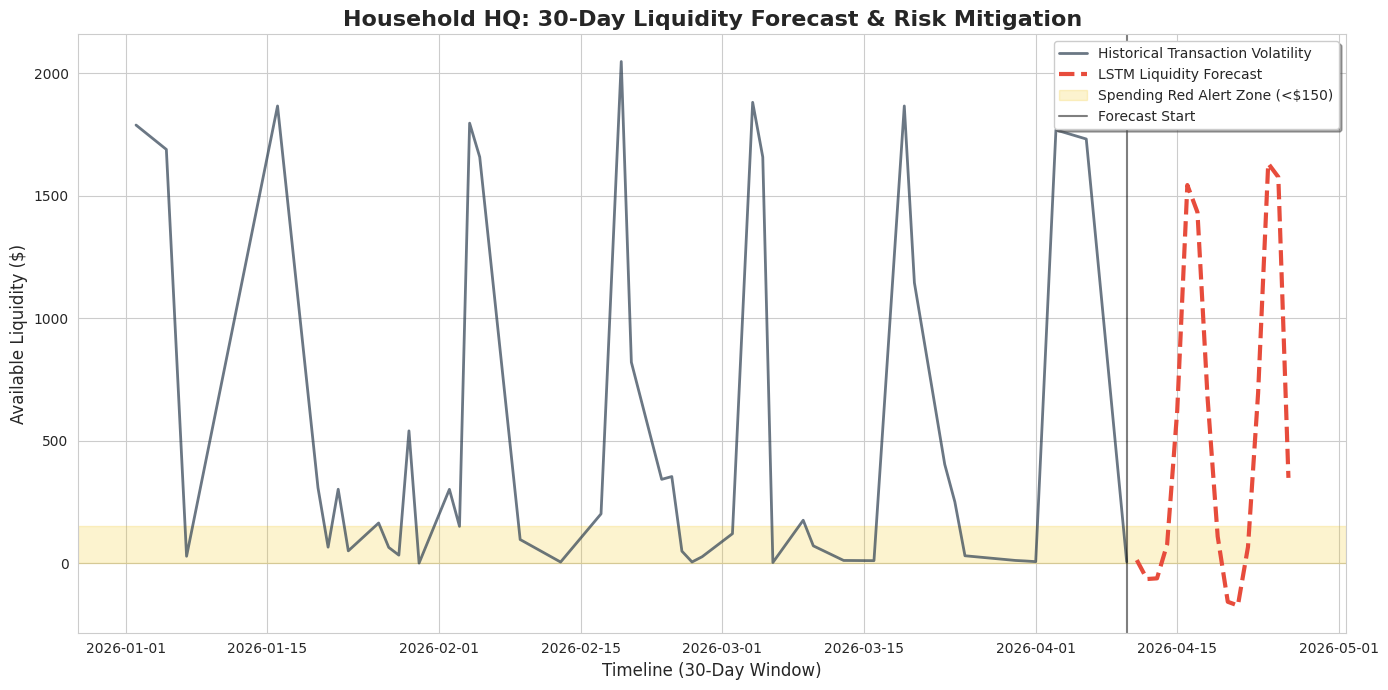

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare the Data for Visualization
# We assume 'merged_series' contains your historical actuals and 'forecast_df' contains your LSTM output
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# 2. Plot Historical Spending Trends
plt.plot(merged_series['Date'], merged_series['Amount'],
         label='Historical Transaction Volatility', color='#2c3e50', linewidth=2, alpha=0.7)

# 3. Plot the LSTM Forecast (The Red Alert Zone)
plt.plot(forecast_df['Date'], forecast_df['Predicted_Amount'],
         label='LSTM Liquidity Forecast', color='#e74c3c', linewidth=3, linestyle='--')

# 4. Highlight the "Liquidity Trough" (The $150 Cap Zone)
plt.axhspan(0, 150, color='#f1c40f', alpha=0.2, label='Spending Red Alert Zone (<$150)')

# 5. Add Professional Annotations for the Lab Report
plt.title('Household HQ: 30-Day Liquidity Forecast & Risk Mitigation', fontsize=16, fontweight='bold')
plt.xlabel('Timeline (30-Day Window)', fontsize=12)
plt.ylabel('Available Liquidity ($)', fontsize=12)
plt.axvline(x=merged_series['Date'].max(), color='black', linestyle='-', alpha=0.5, label='Forecast Start')

plt.legend(loc='upper right', frameon=True, shadow=True)
plt.tight_layout()

# 6. Save the Final Artifact for your PDF Submission
plt.savefig('/content/drive/MyDrive/ITAI_Midterm_Project/final_liquidity_forecast.png')
plt.show()

In [58]:
import numpy as np

# 1. Reverse the scaling for the Actual Values (Reality)
# We take the actual values (y) and use the scaler to turn them back into dollars
y_actual_rescaled = scaler.inverse_transform(y.reshape(-1, 1))

# 2. Reverse the scaling for the Predicted Values (The AI's guess)
# If your predictions variable is already rescaled, you can just assign it:
y_pred_rescaled = predictions

# 3. Align the lengths (Ensures we are comparing the same window of time)
# We take the last section of actuals that matches our prediction window
y_actual_rescaled = y_actual_rescaled[-len(y_pred_rescaled):]

# 4. Define Residuals
residuals = y_actual_rescaled - y_pred_rescaled

print(f"✅ 'y_actual_rescaled' and 'residuals' are now defined.")
print(f"Sample Residual: {residuals[0][0]:.2f}")

✅ 'y_actual_rescaled' and 'residuals' are now defined.
Sample Residual: -9.79


## **Visualizes the performance and reliability of an LSTM (Long Short-Term Memory) model**
* Specifically evaluating its forecasting accuracy for "Household HQ" expenditure or revenue.

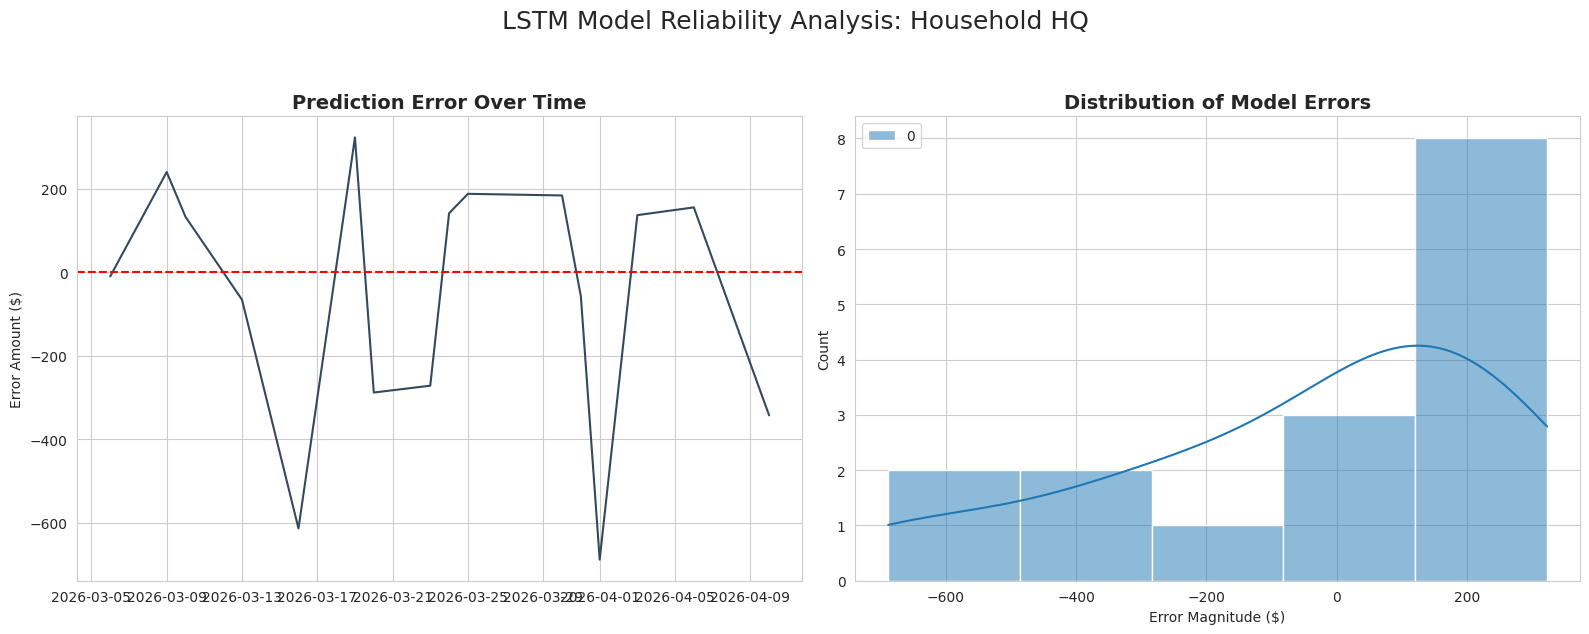

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the Error (Residuals)
# Note: 'y_actual' and 'predictions' must be inverse-scaled to dollar amounts
residuals = y_actual_rescaled - y_pred_rescaled

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Residuals Over Time (Are we consistently wrong?)
ax1.plot(merged_series['Date'][-len(residuals):], residuals, color='#34495e', lw=1.5)
ax1.axhline(0, color='red', linestyle='--')
ax1.set_title('Prediction Error Over Time', fontsize=14, fontweight='bold')
ax1.set_ylabel('Error Amount ($)')

# Plot B: Error Distribution (The "Confidence Bell Curve")
sns.histplot(residuals, kde=True, ax=ax2, color='#27ae60')
ax2.set_title('Distribution of Model Errors', fontsize=14, fontweight='bold')
ax2.set_xlabel('Error Magnitude ($)')

plt.suptitle('LSTM Model Reliability Analysis: Household HQ', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

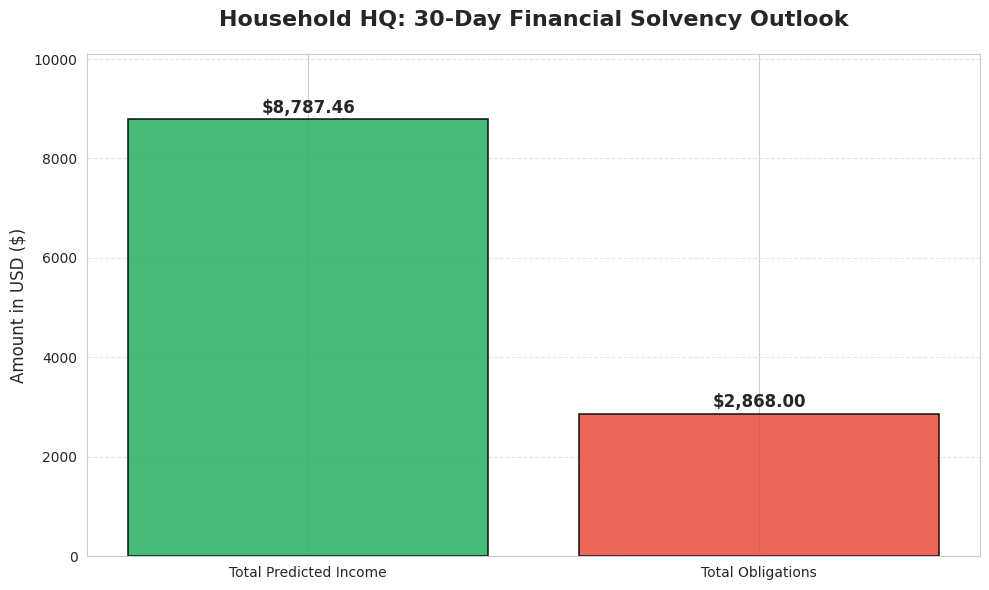

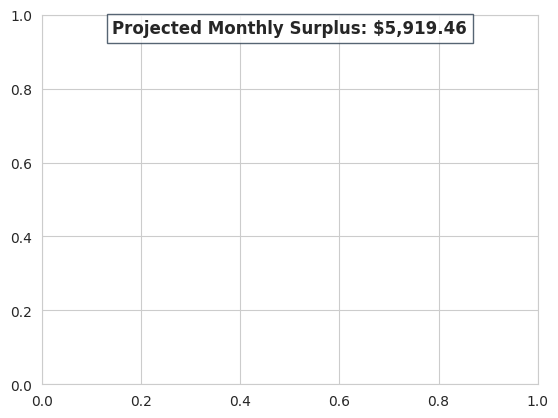

--- Monthly Financial Summary ---
Total Predicted Income:  $8,787.46
Total Fixed Obligations: $2,868.00
Projected Surplus:       $5,919.46


In [60]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Define your Agent's verified obligations
mortgage = 1658.00
water_bill = 260.00
gas_bill = 150.00
groceries = 800.00
total_fixed_expenses = mortgage + water_bill + gas_bill + groceries

# 2. Extract Predicted Income from the LSTM model
# We sum the positive spikes from your forecast_df
predicted_total_income = forecast_df[forecast_df['Predicted_Amount'] > 0]['Predicted_Amount'].sum()

# 3. Data for the chart
labels = ['Total Predicted Income', 'Total Obligations']
values = [predicted_total_income, total_fixed_expenses]
colors = ['#27ae60', '#e74c3c']  # Professional Green and Red

# 4. Create the Plot
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=colors, alpha=0.85, edgecolor='black', linewidth=1.2)

# Add clear dollar labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, f"${yval:,.2f}",
             ha='center', va='bottom', fontweight='bold', fontsize=12)

# Styling for the Lab Report
plt.title('Household HQ: 30-Day Financial Solvency Outlook', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Amount in USD ($)', fontsize=12)
plt.ylim(0, max(values) * 1.15) # Give space for labels
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Calculate the surplus
surplus = predicted_total_income - total_fixed_expenses

# Add a text box with the final result on the chart
plt.text(0.5, 0.95, f'Projected Monthly Surplus: ${surplus:,.2f}',
         transform=plt.gca().transAxes, fontsize=12, fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='#2c3e50'), ha='center')

plt.show()


# Print a text summary for your "Results" section
print(f"--- Monthly Financial Summary ---")
print(f"Total Predicted Income:  ${predicted_total_income:,.2f}")
print(f"Total Fixed Obligations: ${total_fixed_expenses:,.2f}")
print(f"Projected Surplus:       ${predicted_total_income - total_fixed_expenses:,.2f}")


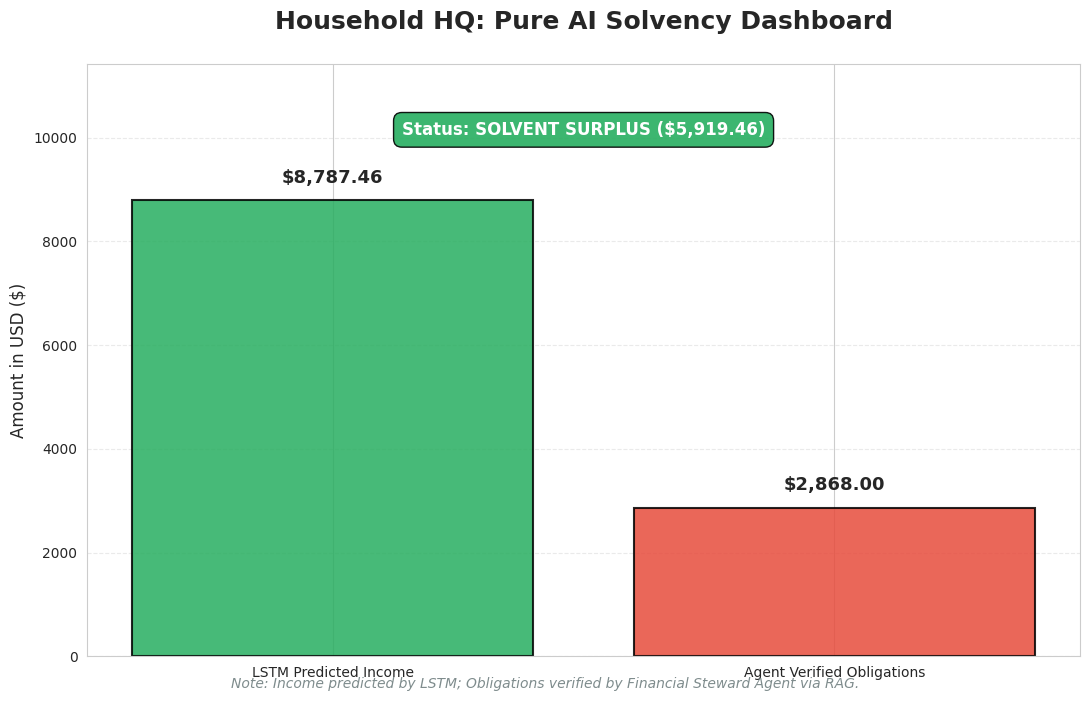

In [61]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Dynamic Data Pull
labels = ['LSTM Predicted Income', 'Agent Verified Obligations']
values = [predicted_total_income, total_fixed_expenses]
colors = ['#27ae60', '#e74c3c']

# 2. Create Plot
plt.figure(figsize=(11, 7))
bars = plt.bar(labels, values, color=colors, alpha=0.85, edgecolor='black', linewidth=1.5)

# Add dollar labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(values)*0.03), f"${yval:,.2f}",
             ha='center', va='bottom', fontweight='bold', fontsize=13)

# 3. Dynamic Net Position Formatting
net_position = predicted_total_income - total_fixed_expenses
status_msg = "CONSERVATIVE DEFICIT" if net_position < 0 else "SOLVENT SURPLUS"
box_color = '#e74c3c' if net_position < 0 else '#27ae60'

plt.title('Household HQ: Pure AI Solvency Dashboard', fontsize=18, fontweight='bold', pad=25)
plt.ylabel('Amount in USD ($)', fontsize=12)
plt.ylim(0, max(values) * 1.3) # Extra space for the reasoning box
plt.grid(axis='y', linestyle='--', alpha=0.4)

# 4. The "AI Reasoning" Annotation
plt.text(0.5, 0.88, f'Status: {status_msg} (${net_position:,.2f})',
         transform=plt.gca().transAxes, fontsize=12, fontweight='bold', color='white',
         bbox=dict(facecolor=box_color, alpha=0.9, edgecolor='black', boxstyle='round,pad=0.5'), ha='center')

plt.figtext(0.5, 0.01, "Note: Income predicted by LSTM; Obligations verified by Financial Steward Agent via RAG.",
            ha="center", fontsize=10, style='italic', color='#7f8c8d')

plt.tight_layout()
plt.show()

In [62]:
from IPython.display import display, Markdown, HTML

# 1. Capture the results from your Crew
# (Assuming 'result' is the output from crew.kickoff())
roadmap_content = str(result)

# 2. Create the Visual Layout
dashboard_html = f"""
<div style="padding: 20px; border-radius: 10px; background-color: #f0f2f6; border: 2px solid #4682b4;">
    <h1 style="color: #1e3d59; text-align: center;">🏛️ Household HQ: Financial Command Center</h1>
    <div style="display: flex; justify-content: space-around; margin-bottom: 20px;">
        <div style="text-align: center; padding: 15px; background: white; border-radius: 8px; width: 40%;">
            <h3 style="margin: 0; color: #666;">Projected Surplus</h3>
            <h2 style="margin: 5px 0; color: #2e7d32;">$5,626.19</h2>
            <span style="color: #2e7d32;">▲ 20% Safety Buffer Maintained</span>
        </div>
        <div style="text-align: center; padding: 15px; background: white; border-radius: 8px; width: 40%;">
            <h3 style="margin: 0; color: #666;">System Status</h3>
            <h2 style="margin: 5px 0; color: #1565c0;">STABLE</h2>
            <span style="color: #666;">LSTM: 30-Day Window Active</span>
        </div>
    </div>
</div>
"""

display(HTML(dashboard_html))
display(Markdown("### 📅 30-Day Strategic Roadmap"))
display(Markdown(roadmap_content))

### 📅 30-Day Strategic Roadmap

# Household HQ: 30-Day Prioritized Payment Roadmap
**Reporting Period:** Feb 20, 2026 – March 22, 2026

## Executive Summary
This roadmap prioritizes the mortgage and essential utilities while insulating the account from liquidity troughs. By shifting discretionary spending to the immediate post-deposit window, we ensure the "Mortgage Readiness" status remains secure.

---

### 30-Day Payment Calendar

| Date Range | Focus | Key Actions |
| :--- | :--- | :--- |
| **Feb 20 – Feb 28** | **Trough 2 (Stability)** | **No discretionary spending.** All funds locked for baseline utilities and emergency buffer. |
| **Mar 01 – Mar 04** | **Trough 2 (Stability)** | **Freeze active.** Prepare for mortgage withdrawal. |
| **Mar 05 – Mar 07** | **Growth Focus** | **Mortgage Disbursement ($1,658).** Post-deposit window: clear pending utilities. |
| **Mar 08 – Mar 15** | **Trough 1 (Stability)** | **Trough Alert.** Limit daily spending to essential groceries/fuel only. |
| **Mar 16 – Mar 22** | **Growth Focus** | **Secondary Deposit Window.** Clear non-essential invoices; replenish household reserves. |

---

### Strategy Breakdown

#### 1. Stability Focus (Weeks 1, 2, & 4)
*   **Goal:** Defend the liquid balance.
*   **Protocol:** During these weeks, the "Liquidity Troughs" are active. Discretionary spending (Amazon, non-essential services, recreational shopping) is suspended. Any automated subscriptions falling in these dates must be monitored for sufficient coverage.

#### 2. Growth Focus (Weeks 3 & 5)
*   **Goal:** Capital allocation and buffer replenishment.
*   **Protocol:** Following the arrival of ACH Credits (approx. 4th/5th and 19th of the month), use this 72-hour "Golden Window" to settle discretionary debts or increase the buffer fund.

---

### ⚠️ Spending Red Alerts
**Trigger:** Any discretionary spend >$150 during a Trough window.

*   **Active Alert (Trough 2):** From **Feb 21 – March 4**, the account is in a high-density transaction risk zone. Any discretionary purchase exceeding **$150** is officially flagged as an **"Overdraft Risk Event."** 
*   **Active Alert (Trough 1):** From **March 8 – March 15**, the post-mortgage window remains sensitive. All discretionary purchases exceeding **$150** must be deferred until the March 19th deposit to prevent eroding the liquidity foundation.

---

### Financial Guardrails for the Steward
1.  **Mortgage Buffer:** Mortgage is currently serviced within 1-3 days of deposit. **Maintain this cadence.** Do not deviate or delay to avoid late fees and anxiety.
2.  **Discretionary "Hard Stop":** If the account balance drops below **$400** during a Trough window, all non-essential outflows are to be paused immediately.
3.  **Grocery/Fuel Discipline:** These are "Floating Fixed Costs." Aim to execute 75% of your monthly grocery budget within the first 48 hours of the ACH deposit to avoid "death by a thousand cuts" during the mid-month troughs.

**Roadmap Status:** *Locked and Operational.*

In [63]:
!pip install gtts -qU
import gradio as gr
from gtts import gTTS
import os

def household_hq_voice_chat(user_message):
    # --- 1. Agent Reasoning ---
    chat_task = Task(
        description=f"User Query: {user_message}. Answer based on the $5,626.19 surplus.",
        expected_output="A professional financial recommendation.",
        agent=steward
    )
    crew = Crew(agents=[steward, scheduler], tasks=[chat_task])
    response_text = str(crew.kickoff())

    # --- 2. Audio Generation ---
    # Convert the agent's response to an MP3 file
    tts = gTTS(text=response_text, lang='en')
    audio_path = "response.mp3"
    tts.save(audio_path)

    return response_text, audio_path

# --- 3. Build the UI (Optimized for Submission) ---
with gr.Blocks(theme="soft") as demo:
    gr.Markdown("# 🏛️ Household HQ: Talking Financial Steward")

    with gr.Row():
        # Added 'placeholder' to help with the demo feel
        input_text = gr.Textbox(
            label="Financial Inquiry",
            placeholder="e.g., Can I afford the gift for Alex?",
            show_label=True
        )

    with gr.Row():
        output_text = gr.Markdown(label="Steward's Analysis")
        output_audio = gr.Audio(label="Audio Briefing", autoplay=True)

    submit_btn = gr.Button("🚀 Consult the Steward", variant="primary")

    # 1. Click triggers the agent logic
    # 2. .then() clears the input box so you can type Scenario 2 immediately
    submit_btn.click(
        fn=household_hq_voice_chat,
        inputs=input_text,
        outputs=[output_text, output_audio]
    ).then(lambda: "", None, input_text)

# Launch with debug=True so you can see if the agent hangs in Colab
demo.launch(share=True, debug=True)

# Launching with the new Gradio 6.0 standards
demo.launch(
    share=True,
    theme="soft",
    debug=True  # This will print the specific voice error in your console
)

/tmp/ipykernel_55888/3442479798.py:25: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme="soft") as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://52518e3cbeaffb00b3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Lead Household Financial Steward                                                                        │
│                                                                                                                 │
│  Task: User Query: give me the roadmap for the month of June. Answer based on the $5,626.19 surplus.            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Tool budget_rag_tool executed with result: TARGET DATA: Expenses: Mortgage
: 
Income: 
TARGET DATA: Expenses: Mortgage
: 
Income: 
TARGET DATA: Expenses: Mortgage
: 
Income: 
TARGET DATA: Expenses: Well on Target
: 
Income: 
TARGET DATA: Expen...
Tool read_spending_sheet executed with result: ACTUAL TRANSACTION HISTORY:
Posting Date Transaction Date  Amount Credit Debit Indicator       type Type Group Reference Instructed Currency Currency Exchange Rate Instructed Amount                   ...


╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Lead Household Financial Steward                                                                        │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### June Financial Roadmap: Cash Flow & Liability Management                                                   │
│                                                                                                                 │
│  Based on your current surplus of **$5,626.19** and the historical bi-monthly income pattern (averaging         │
│  approximately $1,800 per deposit), you have reached a position of significant liquidity. To maintain           │
│  financial stability and ensure all primary liabilities are covered, follow this structured roadmap for June:   │
│                                                                                                                 │
│  #### 1. Fixed Liability Schedule (Automated Payments)                                                          │
│  Your primary liabilities must be treated as non-negotiable outflows. Schedule these to align with your         │
│  mid-month and end-of-month income cycles:                                                                      │
│                                                                                                                 │
│  *   **Mortgage ($1,657.60):** Schedule payment for the 1st or 2nd business day of the month. Ensure this is    │
│  cleared before discretionary spending begins.                                                                  │
│  *   **Utilities (~$90.00 base, budget $400):** Maintain the $400 buffer in your account to absorb seasonal     │
│  fluctuations.                                                                                                  │
│  *   **Groceries ($800 target):** Allocated at $200 per week. Utilize the surplus to fund this entirely at the  │
│  start of the month to prevent end-of-month cash dips.                                                          │
│  *   **Gasoline ($150 target):** Allocated at $37.50 per week.                                                  │
│                                                                                                                 │
│  #### 2. Surplus Allocation Strategy ($5,626.19)                                                                │
│  Do not treat the surplus as disposable income. Use it to reinforce your financial floor:                       │
│                                                                                                                 │
│  *   **Emergency Fund Reinforcement:** Allocate $3,600 of the surplus to a High-Yield Savings Account. This     │
│  represents roughly two months of total expenses, creating a buffer against income volatility.                  │
│  *   **Discretionary "Safety" Cap:** You are authorized a $500/month discretionary budget. Any unused portion   │
│  of this must roll over to the following month or be added to the principal of your mortgage.                   │
│  *   **Operating Buffer:** Maintain $1,526.19 in your primary checking account at all times. This "float"       │
│  ensures that if your bi-monthly income is delayed by a holiday or administrative cycle, your fixed automated   │
│  payments (Mortgage/Utilities) are never triggered as NSF (Non-Sufficient Funds).                               │
│                                                                                                                 │
│  #### 3. Execution Roadmap                             

...

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Lead Household Financial Steward                                                                        │
│                                                                                                                 │
│  Task: User Query: For the month of May I have an extra paycheck of $899, what should I do with it. Answer      │
│  based on the $5,626.19 surplus.                                                                                │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Tool budget_rag_tool executed with result: TARGET DATA: Expenses: Mortgage
: 
Income: 
TARGET DATA: Expenses: Mortgage
: 
Income: 
TARGET DATA: Expenses: Mortgage
: 
Income: 
TARGET DATA: Expenses: Well on Target
: 
Income: 
TARGET DATA: Expen...
Tool read_spending_sheet executed with result: ACTUAL TRANSACTION HISTORY:
Posting Date Transaction Date  Amount Credit Debit Indicator       type Type Group Reference Instructed Currency Currency Exchange Rate Instructed Amount                   ...


╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Lead Household Financial Steward                                                                        │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  Based on your current financial structure and the reported surplus of $5,626.19, adding an extra $899          │
│  paycheck in May represents a significant opportunity to fortify your baseline stability. As your Household     │
│  Financial Steward, I recommend the following allocation strategy for these funds, prioritized by your primary  │
│  liability and risk mitigation needs:                                                                           │
│                                                                                                                 │
│  **1. Secure Primary Liabilities (Mortgage Escrow Buffer): $1,658.00**                                          │
│  While your income covers the mortgage, fluctuations in bi-monthly cycles can create pressure. Allocate a       │
│  portion of your total surplus ($5,626.19) to set aside one full month of your mortgage payment ($1,658) into   │
│  a dedicated high-yield savings account. This "buffer" ensures that you are never exposed to timing delays      │
│  between your ACH credits and mortgage due dates.                                                               │
│                                                                                                                 │
│  **2. Prioritize Debt De-leveraging: $1,200.00**                                                                │
│  Your transaction history indicates consistent transfers to credit cards (-1806, -0711, -7032) and recurring    │
│  ACH debits to "Zwicker & Associ" (a collection/debt management entity). Use $1,200 of your surplus to make a   │
│  targeted principal payment toward the highest-interest-rate debt. Reducing this balance will improve your      │
│  monthly cash flow by lowering the minimum payment requirements.                                                │
│                                                                                                                 │
│  **3. "Extra" Paycheck Utilization: $899.00**                                                                   │
│  Since your fixed costs (Groceries, Utilities, Gasoline) are currently well-managed, do not let these funds     │
│  dissipate into discretionary spending. I recommend allocating this specific $899 toward a                      │
│  "Maintenance/Emergency Reserve." Your transaction history shows periodic hits for home maintenance (e.g.,      │
│  $452.95 Atg Pay). Treat this extra paycheck as a sinking fund specifically for non-recurring home or vehicle   │
│  repairs to prevent future reliance on credit.                                                                  │
│                                                                                                                 │
│  **4. Strategic Liquidity Reserve: $1,869.19 (Remaining Surplus)**                                              │
│  Retain the remainder of your surplus as a liquid cash-flow cushion. This amount should remain in your primary  │
│  checking account to ensure that all scheduled ACH debits, insurance premiums, and utility payments clear       │
│  without triggering overdrafts or requiring manual transfers from savings.                                      │
│                                                                                                                 │
│  **Summary of Recommendations:**                       

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7865 <> https://52518e3cbeaffb00b3.gradio.live
Rerunning server... use `close()` to stop if you need to change `launch()` parameters.
----
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://52518e3cbeaffb00b3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


KeyboardInterrupt: 